In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Load and explore dataset
def load_and_explore(filename):
    df = pd.read_csv(filename)
    print("Dataset info : ")
    print(f"shape: {df.shape} ")
    print(f"Columns: {df.columns.tolist()}")
    print("\nFirst five rows: ")
    print(df.head())
    print("\nMissing value : ")
    print(df.isnull().sum())
    return df
filename = "C:/Users/Lenovo/Downloads/supermarket_sales.csv"
load_and_explore(filename)

Dataset info : 
shape: (2000, 14) 
Columns: ['Invoice_ID', 'Branch', 'City', 'Customer_Type', 'Gender', 'Product_Line', 'Unit_Price', 'Quantity', 'Tax', 'Total', 'Date', 'Time', 'Payment', 'Rating']

First five rows: 
  Invoice_ID Branch       City Customer_Type  Gender         Product_Line  \
0  INV000001      B   Mandalay        Member    Male     Food & Beverages   
1  INV000002      C   Mandalay        Member  Female     Food & Beverages   
2  INV000003      C  Naypyitaw        Normal  Female  Fashion Accessories   
3  INV000004      B  Naypyitaw        Member  Female     Food & Beverages   
4  INV000005      C     Yangon        Normal  Female     Food & Beverages   

   Unit_Price  Quantity   Tax   Total        Date   Time      Payment  Rating  
0       69.36         3  7.28  119.58  2023-08-08  18:54  Credit card     8.4  
1       35.25         1  6.62  137.13  2023-02-09  18:44  Credit card     4.3  
2       57.56         8  4.66  490.48  2023-08-24  16:16         Cash     9.6  

,Invoice_ID,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Tax,Total,Date,Time,Payment,Rating
0,INV000001,B,Mandalay,Member,Male,Food & Beverages,69.36,3,7.28,119.58,2023-08-08,18:54,Credit card,8.4
1,INV000002,C,Mandalay,Member,Female,Food & Beverages,35.25,1,6.62,137.13,2023-02-09,18:44,Credit card,4.3
2,INV000003,C,Naypyitaw,Normal,Female,Fashion Accessories,57.56,8,4.66,490.48,2023-08-24,16:16,Cash,9.6
3,INV000004,B,Naypyitaw,Member,Female,Food & Beverages,16.60,5,8.57,142.54,2023-02-09,11:35,Cash,4.5
4,INV000005,C,Yangon,Normal,Female,Food & Beverages,49.07,1,3.70,24.43,2023-07-04,8:56,Credit card,5.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,INV001996,C,Yangon,Member,Female,Sports & Travel,57.65,9,1.45,69.66,2023-06-29,19:14,Cash,7.7
1996,INV001997,A,Yangon,Member,Female,Fashion Accessories,96.38,4,7.32,139.45,2023-04-08,13:48,Credit card,6.4
1997,INV001998,C,Yangon,Member,Female,Home & Lifestyle,23.31,7,4.88,289.58,2023-03-24,12:26,Cash,4.2
1998,INV001999,C,Yangon,Normal,Female,Food & Beverages,71.82,4,5.50,400.04,2023-10-04,10:35,Cash,8.3


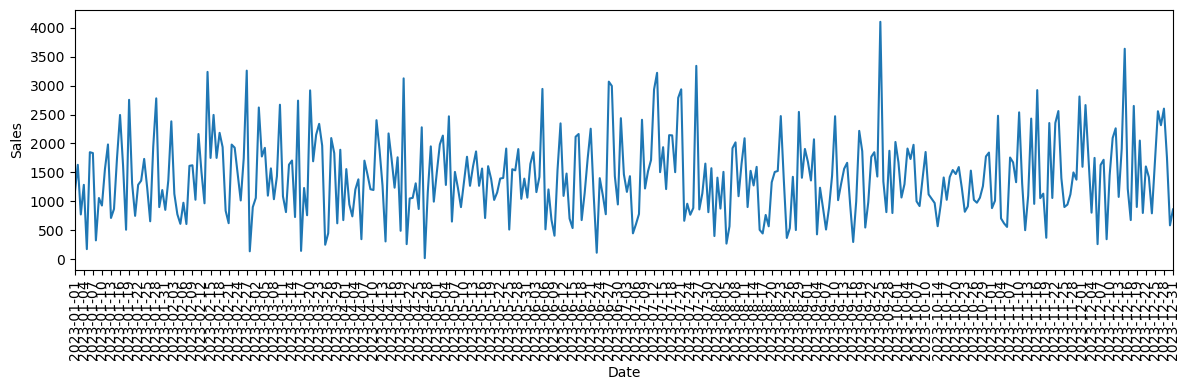

(Date
 2023-01-01    1145.28
 2023-01-02    1631.56
 2023-01-03     775.06
 2023-01-04    1285.96
 2023-01-05     176.61
                ...   
 2023-12-27    2315.07
 2023-12-28    2601.27
 2023-12-29    1754.42
 2023-12-30     587.29
 2023-12-31     862.20
 Name: Total, Length: 364, dtype: float64,
              Product_Line  Quantity
 0         Health & Beauty      1866
 1         Sports & Travel      1737
 2  Electronic Accessories      1691
 3        Home & Lifestyle      1654
 4        Food & Beverages      1618
 5     Fashion Accessories      1500,
 Customer_Type
 Member    257.288153
 Normal    262.078768
 Name: Total, dtype: float64)

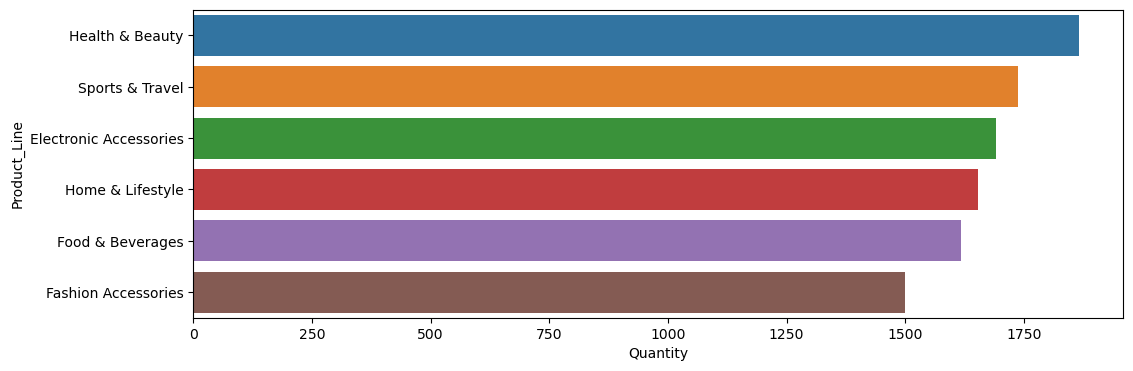

In [22]:
#Sales analysis example
df = pd.read_csv(filename)
def analyze_sales(df):
    #Daily sales
    start_date = '2023-01-01'
    end_date = '2023-12-31'
    df['Date'] = pd.to_datetime(df['Date'])
    daily_sales=df.groupby('Date')['Total'].sum()
    plt.figure(figsize = (12,4))
    plt.plot(daily_sales)
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.xticks(
    ticks=daily_sales.index[::3],
    rotation=90
)
    # 🔑 Force x-axis to start from start_date (origin)
    plt.xlim(pd.to_datetime(start_date), pd.to_datetime(end_date))
    plt.tight_layout()
    plt.show()
    
    #Best Product
    best_products = df.groupby('Product_Line')['Quantity'].sum().sort_values(ascending = False).reset_index()

    #we can analyse best product by using barplot
    plt.figure(figsize= (12,4))
    sns.barplot(data= best_products, x = 'Quantity', y= 'Product_Line')
    
    #customer spending 
    avg_spending = df.groupby('Customer_Type')['Total'].mean()
    
    return daily_sales, best_products, avg_spending

analyze_sales(df)

Customer avg Sales is  Customer_Type
Member    257.288153
Normal    262.078768
Name: Total, dtype: float64

Total Sales of customer who are members is: 261919.33999999997

Total Sales of customer who are Normal is: 257361.35

                Total_sales  Avg_Bill_Value  Avg_Quantity  Avg_Rating
Customer_Type                                                       
Member           261919.34      257.288153      5.003929    6.945383
Normal           257361.35      262.078768      5.063136    6.970265

 Gender Based analysis of sales

         Total_sales  Avg_Bill_Value  Avg_Quantity  Avg_Rating
Gender                                                       
Female    264337.27      259.408508      5.047105    7.028557
Male      254943.42      259.881162      5.018349    6.883894
    Hours  Transanction_count
0       8                 179
1       9                 158
2      10                 166
3      11                 146
4      12                 179
5      13                 170
6   

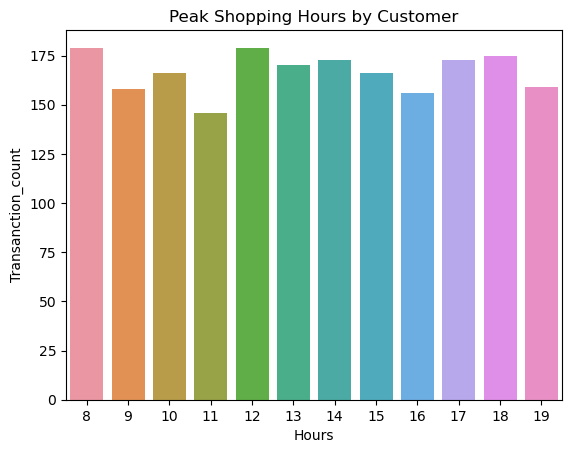


 Hourly sales by Gender


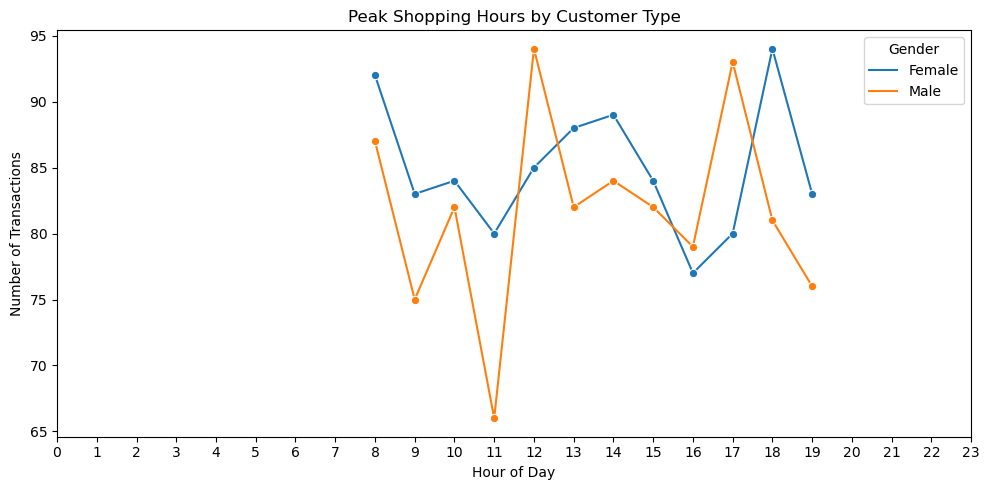

In [56]:
def Customer_Behavior_Analysis(df):
    #Customer type analysis (Member vs Normal)
    customer_avg_sales = df.groupby("Customer_Type")['Total'].mean()
    print("Customer avg Sales is ",customer_avg_sales)
    #Total sales of customer type Member
    customer_Member_sales = df[df["Customer_Type"]=="Member"]["Total"].sum()
    print(f"\nTotal Sales of customer who are members is: {customer_Member_sales}")
    #Total sales of customer type Normal
    customer_Normal_sales = df[df["Customer_Type"]=="Normal"]["Total"].sum()
    print(f"\nTotal Sales of customer who are Normal is: {customer_Normal_sales}")
    
    # Group by customer analysis
    customer_analysis = df.groupby("Customer_Type").agg(
        Total_sales = ('Total', 'sum'),
        Avg_Bill_Value = ('Total', 'mean'),
        Avg_Quantity = ('Quantity', 'mean'),
       
        Avg_Rating = ('Rating', 'mean'))
    print("\n",customer_analysis)
    
    #Spending behavior by gender
    print("\n Gender Based analysis of sales")
    customer_analysis_gender = df.groupby("Gender").agg(
        Total_sales = ('Total', 'sum'),
        Avg_Bill_Value = ('Total', 'mean'),
        Avg_Quantity = ('Quantity', 'mean'),
       
        Avg_Rating = ('Rating', 'mean'))
    print("\n",customer_analysis_gender)
    
    #Analysis of peak-hours sales
    df['Time'] = pd.to_datetime(df['Time'])
    
    #Extract the hours of sales
    df['Hours'] = df['Time'].dt.hour
    
    hourly_transanction = df.groupby(['Hours']).size().reset_index(name = 'Transanction_count')
    print(hourly_transanction)
    print("\nwe can see the peakhour sales")
    
    sns.barplot(x =hourly_transanction.Hours, y=hourly_transanction.Transanction_count)
    plt.title("Peak Shopping Hours by Customer")
    plt.show()
    
    #Hourly transanction Gender basis
    print("\n Hourly sales by Gender")
    Hourly_sales_Gender = df.groupby(['Gender', 'Hours']).size().reset_index(name = 'Hourly_Transanction_count')
    
    plt.figure(figsize=(10,5))
    sns.lineplot(
    data=Hourly_sales_Gender,
    x='Hours',
    y='Hourly_Transanction_count',
    hue='Gender',
    marker='o'
)
    plt.title("Peak Shopping Hours by Customer Type")
    plt.xlabel("Hour of Day")
    plt.ylabel("Number of Transactions")
    plt.xticks(range(0,24))
    plt.tight_layout()
    plt.show()
    
    
    
Customer_Behavior_Analysis(df)